# Speaker Embedding Visualization

Visualize cosine distances and DBSCAN clustering of speaker embeddings from diarized audio files.

Each diarized file contains segments with 256-dimensional speaker embeddings produced by the diarization pipeline. We:
1. Load all segments across recordings
2. Compute pairwise cosine distance matrices
3. Run DBSCAN (`eps=0.35`, `min_samples=1`) — matching the app's parameters
4. Reduce to 2D/3D with UMAP for scatter plots
5. Visualize per-file and cross-file clustering

In [16]:
import json
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_distances
from scipy.spatial.distance import squareform, pdist
import umap

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

## 1. Load diarized data

In [17]:
DIARIZED_DIR = os.path.join("..", "tests", "files", "diarized")

rows = []
for fp in sorted(glob.glob(os.path.join(DIARIZED_DIR, "Enregistrement *.json"))):
    fname = os.path.basename(fp)
    with open(fp) as f:
        segments = json.load(f)
    for i, seg in enumerate(segments):
        rows.append({
            "file": fname.replace(".json", ""),
            "seg_idx": i,
            "offset_ms": seg["offset"],
            "duration_ms": seg["duration"],
            "embedding": np.array(seg["embedding"]),
        })

df = pd.DataFrame(rows)
embeddings = np.stack(df["embedding"].values)

print(f"Loaded {len(df)} segments from {df['file'].nunique()} files")
print(f"Embedding shape: {embeddings.shape}")
df[["file", "seg_idx", "offset_ms", "duration_ms"]].head(10)

Loaded 23 segments from 9 files
Embedding shape: (23, 256)


,file,seg_idx,offset_ms,duration_ms
0,Enregistrement 1,0,5318,3336
1,Enregistrement 1,1,9281,4262
2,Enregistrement 2,0,5470,2388
3,Enregistrement 2,1,8248,3442
4,Enregistrement 3,0,999,13175
5,Enregistrement 4,0,11532,5403
6,Enregistrement 4,1,17375,8788
7,Enregistrement 5,0,2523,1355
8,Enregistrement 5,1,4640,3878
9,Enregistrement 5,2,9230,6264


## 2. Pairwise cosine distance matrix (all segments)

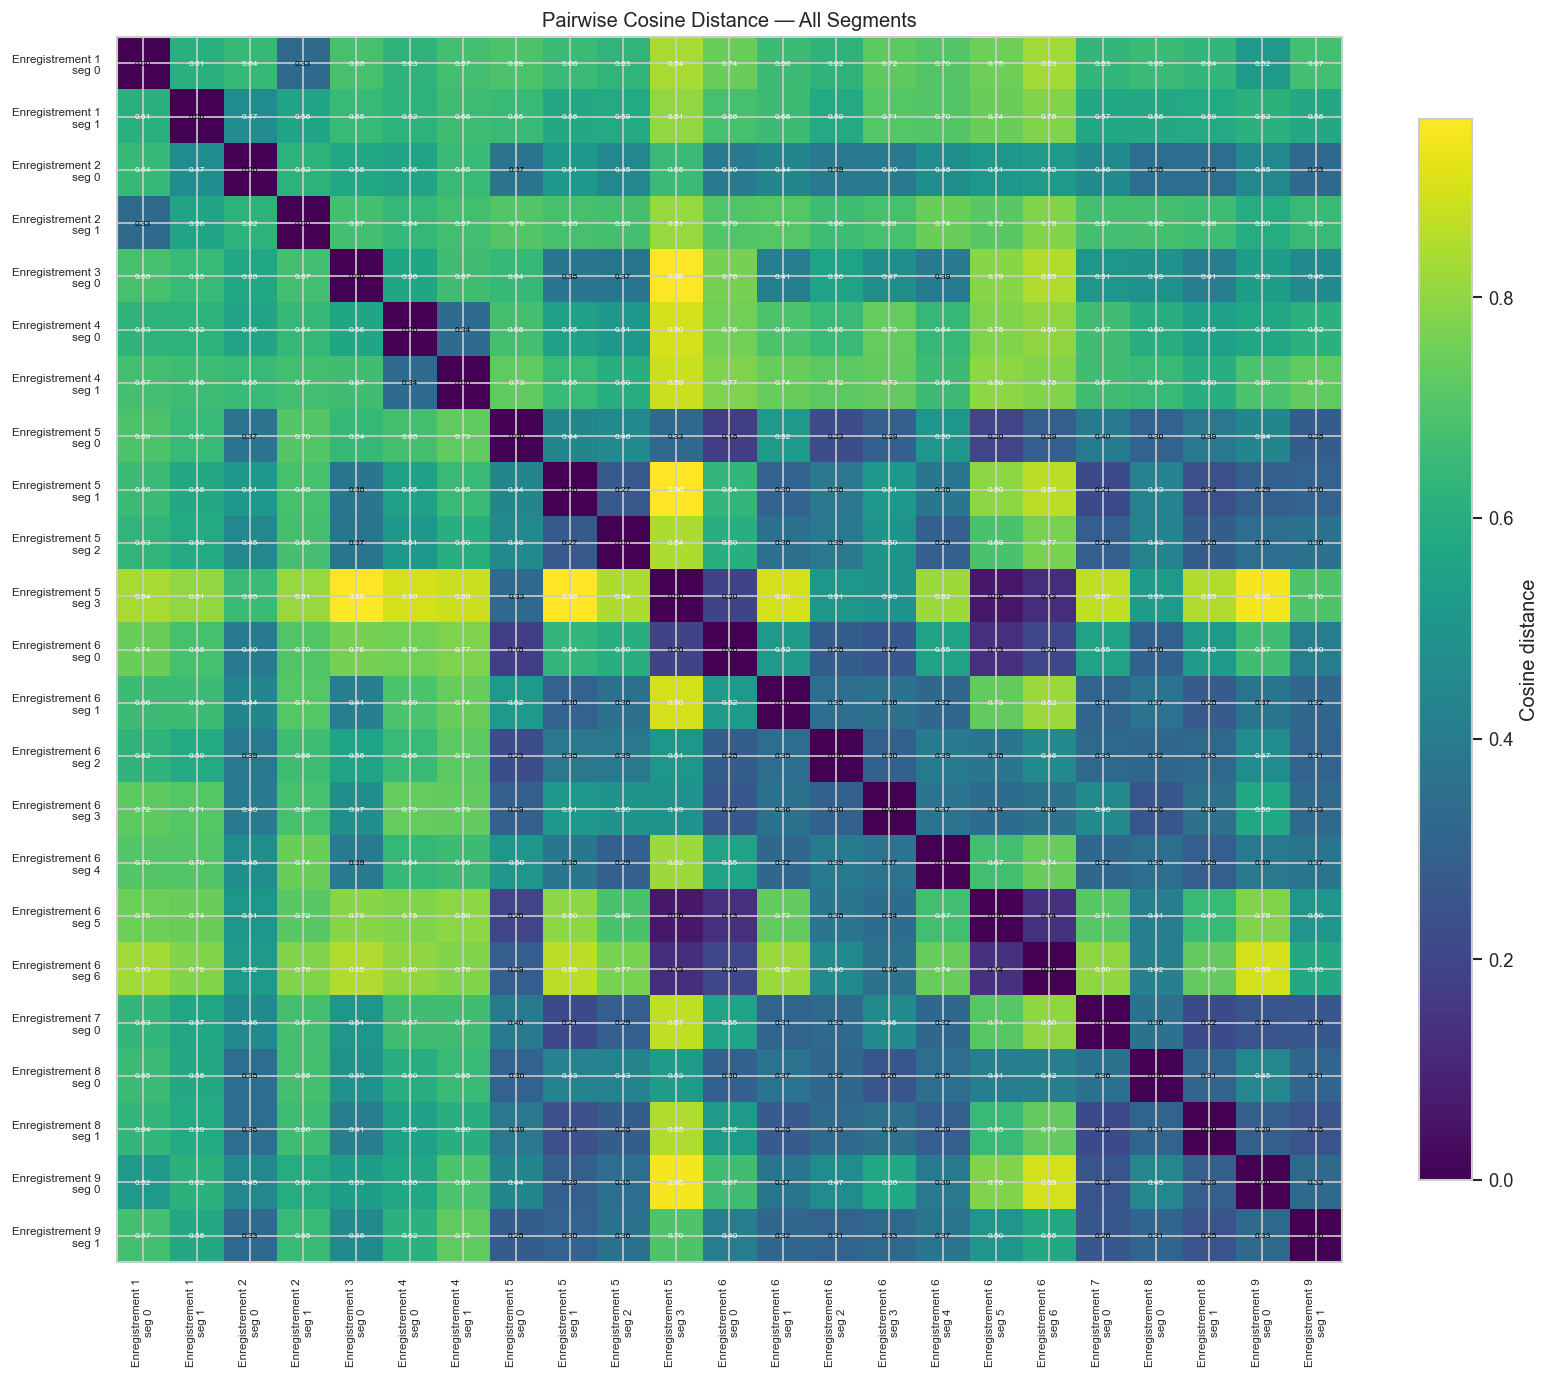

In [18]:
dist_matrix = cosine_distances(embeddings)

labels = [f"{r.file}\nseg {r.seg_idx}" for _, r in df.iterrows()]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(dist_matrix, cmap="viridis", vmin=0)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticklabels(labels, fontsize=7)
ax.set_title("Pairwise Cosine Distance — All Segments")
fig.colorbar(im, ax=ax, shrink=0.8, label="Cosine distance")

# Annotate cells with distance values
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{dist_matrix[i, j]:.2f}",
                ha="center", va="center", fontsize=5,
                color="white" if dist_matrix[i, j] > 0.4 else "black")

plt.tight_layout()
plt.show()

## 3. Distance distribution

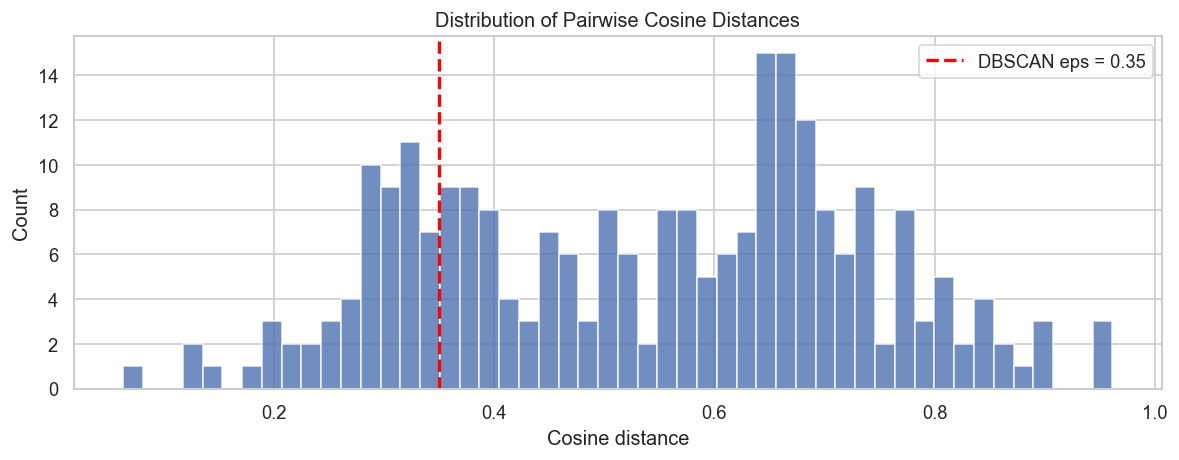

Distance stats:
  min  = 0.0635
  max  = 0.9613
  mean = 0.5368
  median = 0.5609
  % < 0.35 (within eps): 22.1%


In [19]:
# Upper-triangle distances (no self-pairs)
upper_tri = dist_matrix[np.triu_indices_from(dist_matrix, k=1)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(upper_tri, bins=50, edgecolor="white", alpha=0.8)
ax.axvline(0.35, color="red", linestyle="--", linewidth=2, label="DBSCAN eps = 0.35")
ax.set_xlabel("Cosine distance")
ax.set_ylabel("Count")
ax.set_title("Distribution of Pairwise Cosine Distances")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Distance stats:")
print(f"  min  = {upper_tri.min():.4f}")
print(f"  max  = {upper_tri.max():.4f}")
print(f"  mean = {upper_tri.mean():.4f}")
print(f"  median = {np.median(upper_tri):.4f}")
print(f"  % < 0.35 (within eps): {100 * (upper_tri < 0.35).mean():.1f}%")

## 4. Linkage strategy comparison

All approaches use a single distance threshold (no `n_clusters` parameter) — they auto-discover
the number of speakers. The difference is how "should these two groups merge?" is decided:

| Linkage | Merge criterion | Risk |
|---------|----------------|------|
| **Single** (≈ DBSCAN) | Closest pair across groups ≤ threshold | Over-merges (chaining) |
| **Average** | Mean pairwise distance ≤ threshold | Balanced |
| **Complete** | Farthest pair across groups ≤ threshold | Over-splits |

In [20]:
from sklearn.cluster import AgglomerativeClustering

THRESHOLD = 0.35

# Ground truth: files 1 & 2 have 2 speakers each, all others have 1
expected_speakers = {
    "Enregistrement 1": 2, "Enregistrement 2": 2, "Enregistrement 3": 1,
    "Enregistrement 4": 1, "Enregistrement 5": 1, "Enregistrement 6": 1,
    "Enregistrement 7": 1, "Enregistrement 8": 1, "Enregistrement 9": 1,
}

strategies = {
    "DBSCAN (≈single)": lambda: DBSCAN(eps=THRESHOLD, min_samples=1, metric="precomputed").fit_predict(dist_matrix),
    "Agglom. single":   lambda: AgglomerativeClustering(n_clusters=None, metric="precomputed", linkage="single",   distance_threshold=THRESHOLD).fit_predict(dist_matrix),
    "Agglom. average":  lambda: AgglomerativeClustering(n_clusters=None, metric="precomputed", linkage="average",  distance_threshold=THRESHOLD).fit_predict(dist_matrix),
    "Agglom. complete": lambda: AgglomerativeClustering(n_clusters=None, metric="precomputed", linkage="complete", distance_threshold=THRESHOLD).fit_predict(dist_matrix),
}

print(f"Threshold = {THRESHOLD}\n")
print(f"{'Strategy':<22} {'Clusters':>8}  {'Correct files':>13}  Details")
print("─" * 85)

for name, fn in strategies.items():
    labels = fn()
    df[f"_c_{name}"] = labels
    n_c = len(set(labels)) - (1 if -1 in labels else 0)

    # Check per-file correctness
    correct = 0
    details = []
    for fname, expected_n in expected_speakers.items():
        sub = df[df["file"] == fname]
        actual_n = sub[f"_c_{name}"].nunique()
        ok = actual_n == expected_n
        if ok:
            correct += 1
        else:
            short = fname.replace("Enregistrement ", "E")
            details.append(f"{short}:{actual_n}≠{expected_n}")

    err_str = ", ".join(details) if details else "all correct ✓"
    print(f"{name:<22} {n_c:>8}  {correct:>8}/{len(expected_speakers):<4}  {err_str}")

# Clean up temp columns
df.drop(columns=[c for c in df.columns if c.startswith("_c_")], inplace=True)

# ── Use average linkage as the winner ──
agg = AgglomerativeClustering(
    n_clusters=None, metric="precomputed",
    linkage="average", distance_threshold=THRESHOLD,
)
df["cluster"] = agg.fit_predict(dist_matrix)
n_clusters = df["cluster"].nunique()
print(f"\n→ Using average linkage: {n_clusters} speakers")

Threshold = 0.35

Strategy               Clusters  Correct files  Details
─────────────────────────────────────────────────────────────────────────────────────
DBSCAN (≈single)              5         9/9     all correct ✓
Agglom. single                5         9/9     all correct ✓
Agglom. average               8         6/9     E5:3≠1, E6:3≠1, E8:2≠1
Agglom. complete             10         5/9     E5:3≠1, E6:4≠1, E8:2≠1, E9:2≠1

→ Using average linkage: 8 speakers


## 5. Speaker Map — linkage comparison (UMAP 2D)

/Users/antonin.riche/Documents/perso/notetaker-v2/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/9p/kmzq67ds4bz3d1fh6lht5y4h0000gq/T/ipykernel_33420/3814267381.py:93: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/antonin.riche/Documents/perso/notetaker-v2/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


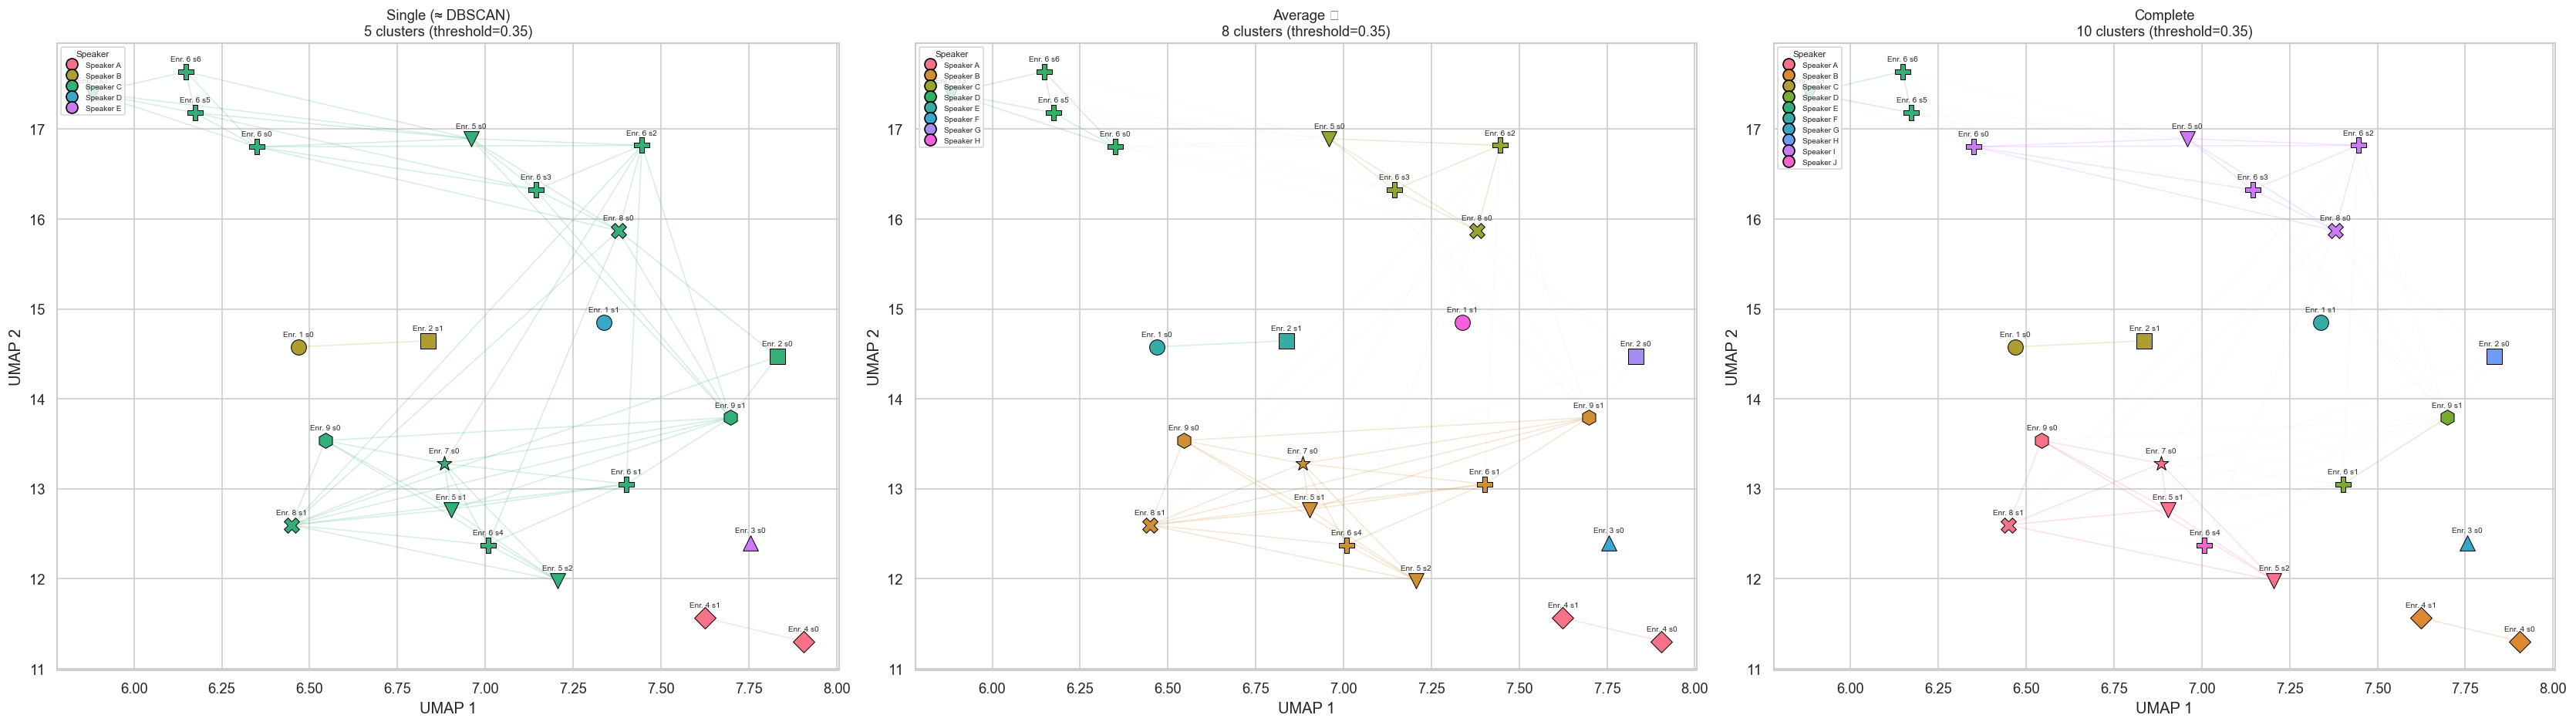

Speaker assignments (average linkage):
  Enregistrement 1: seg 0 → Speaker E, seg 1 → Speaker H
  Enregistrement 2: seg 0 → Speaker G, seg 1 → Speaker E
  Enregistrement 3: seg 0 → Speaker F
  Enregistrement 4: seg 0 → Speaker A, seg 1 → Speaker A
  Enregistrement 5: seg 0 → Speaker C, seg 1 → Speaker B, seg 2 → Speaker B, seg 3 → Speaker D
  Enregistrement 6: seg 0 → Speaker D, seg 1 → Speaker B, seg 2 → Speaker C, seg 3 → Speaker C, seg 4 → Speaker B, seg 5 → Speaker D, seg 6 → Speaker D
  Enregistrement 7: seg 0 → Speaker B
  Enregistrement 8: seg 0 → Speaker C, seg 1 → Speaker B
  Enregistrement 9: seg 0 → Speaker B, seg 1 → Speaker B


In [21]:
from matplotlib.lines import Line2D
from sklearn.cluster import AgglomerativeClustering

reducer = umap.UMAP(
    n_components=2, metric="cosine",
    n_neighbors=min(5, len(df) - 1), min_dist=0.1, random_state=42,
)
coords_2d = reducer.fit_transform(embeddings)
df["umap_x"] = coords_2d[:, 0]
df["umap_y"] = coords_2d[:, 1]

THRESHOLD = 0.35

# Compute all linkage variants
linkages = [
    ("Single (≈ DBSCAN)", "single"),
    ("Average ✓", "average"),
    ("Complete", "complete"),
]
cluster_cols = {}
for label, linkage in linkages:
    col = f"_cl_{linkage}"
    agg = AgglomerativeClustering(
        n_clusters=None, metric="precomputed",
        linkage=linkage, distance_threshold=THRESHOLD,
    )
    df[col] = agg.fit_predict(dist_matrix)
    cluster_cols[label] = col

df["short_file"] = df["file"].str.replace("Enregistrement ", "Enr. ")
df["point_label"] = df["short_file"] + " s" + df["seg_idx"].astype(str)

file_names = sorted(df["file"].unique())
markers_list = ["o", "s", "^", "D", "v", "P", "*", "X", "h"]
file_markers = {f: markers_list[i % len(markers_list)] for i, f in enumerate(file_names)}

# Neighbor edges
neighbor_edges = []
for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if dist_matrix[i, j] <= THRESHOLD:
            neighbor_edges.append((i, j))

def make_colors(col):
    ids = sorted(df[col].unique())
    pal = sns.color_palette("husl", n_colors=len(ids))
    mapping = {cid: f"Speaker {chr(65 + i)}" for i, cid in enumerate(ids)}
    names = [mapping[c] for c in ids]
    colors = {mapping[cid]: pal[i] for i, cid in enumerate(ids)}
    return mapping, names, colors

fig, axes = plt.subplots(1, 3, figsize=(28, 8))

for ax, (title, col) in zip(axes, cluster_cols.items()):
    mapping, sp_names, sp_colors = make_colors(col)
    df["_sp"] = df[col].map(mapping)

    # Edges
    for i, j in neighbor_edges:
        same = df.iloc[i][col] == df.iloc[j][col]
        color = sp_colors[df.iloc[i]["_sp"]] if same else "#dddddd"
        ax.plot(
            [df.iloc[i]["umap_x"], df.iloc[j]["umap_x"]],
            [df.iloc[i]["umap_y"], df.iloc[j]["umap_y"]],
            color=color, alpha=0.2 if same else 0.1, linewidth=1, zorder=1,
        )

    # Points
    for _, row in df.iterrows():
        ax.scatter(
            row["umap_x"], row["umap_y"],
            c=[sp_colors[row["_sp"]]], marker=file_markers[row["file"]],
            s=140, edgecolors="black", linewidth=0.6, zorder=3,
        )
        ax.annotate(
            row["point_label"], (row["umap_x"], row["umap_y"]),
            fontsize=6, ha="center", va="bottom",
            textcoords="offset points", xytext=(0, 7),
        )

    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=sp_colors[s],
               markersize=9, markeredgecolor="black", label=s)
        for s in sp_names
    ]
    ax.legend(handles=handles, title="Speaker", loc="upper left", fontsize=6, title_fontsize=7)
    n_c = df[col].nunique()
    ax.set_title(f"{title}\n{n_c} clusters (threshold={THRESHOLD})", fontsize=11)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

df.drop(columns=["_sp"] + list(cluster_cols.values()), inplace=True)
plt.tight_layout()
plt.show()

# Final speaker labels
speaker_names = {}
for i, cid in enumerate(sorted(df["cluster"].unique())):
    speaker_names[cid] = f"Speaker {chr(65 + i)}"
df["speaker"] = df["cluster"].map(speaker_names)

print("Speaker assignments (average linkage):")
for fname in file_names:
    sub = df[df["file"] == fname]
    segs = ", ".join(f"seg {r.seg_idx} → {r.speaker}" for _, r in sub.iterrows())
    print(f"  {fname}: {segs}")

## 6. Per-file intra-file distance heatmaps

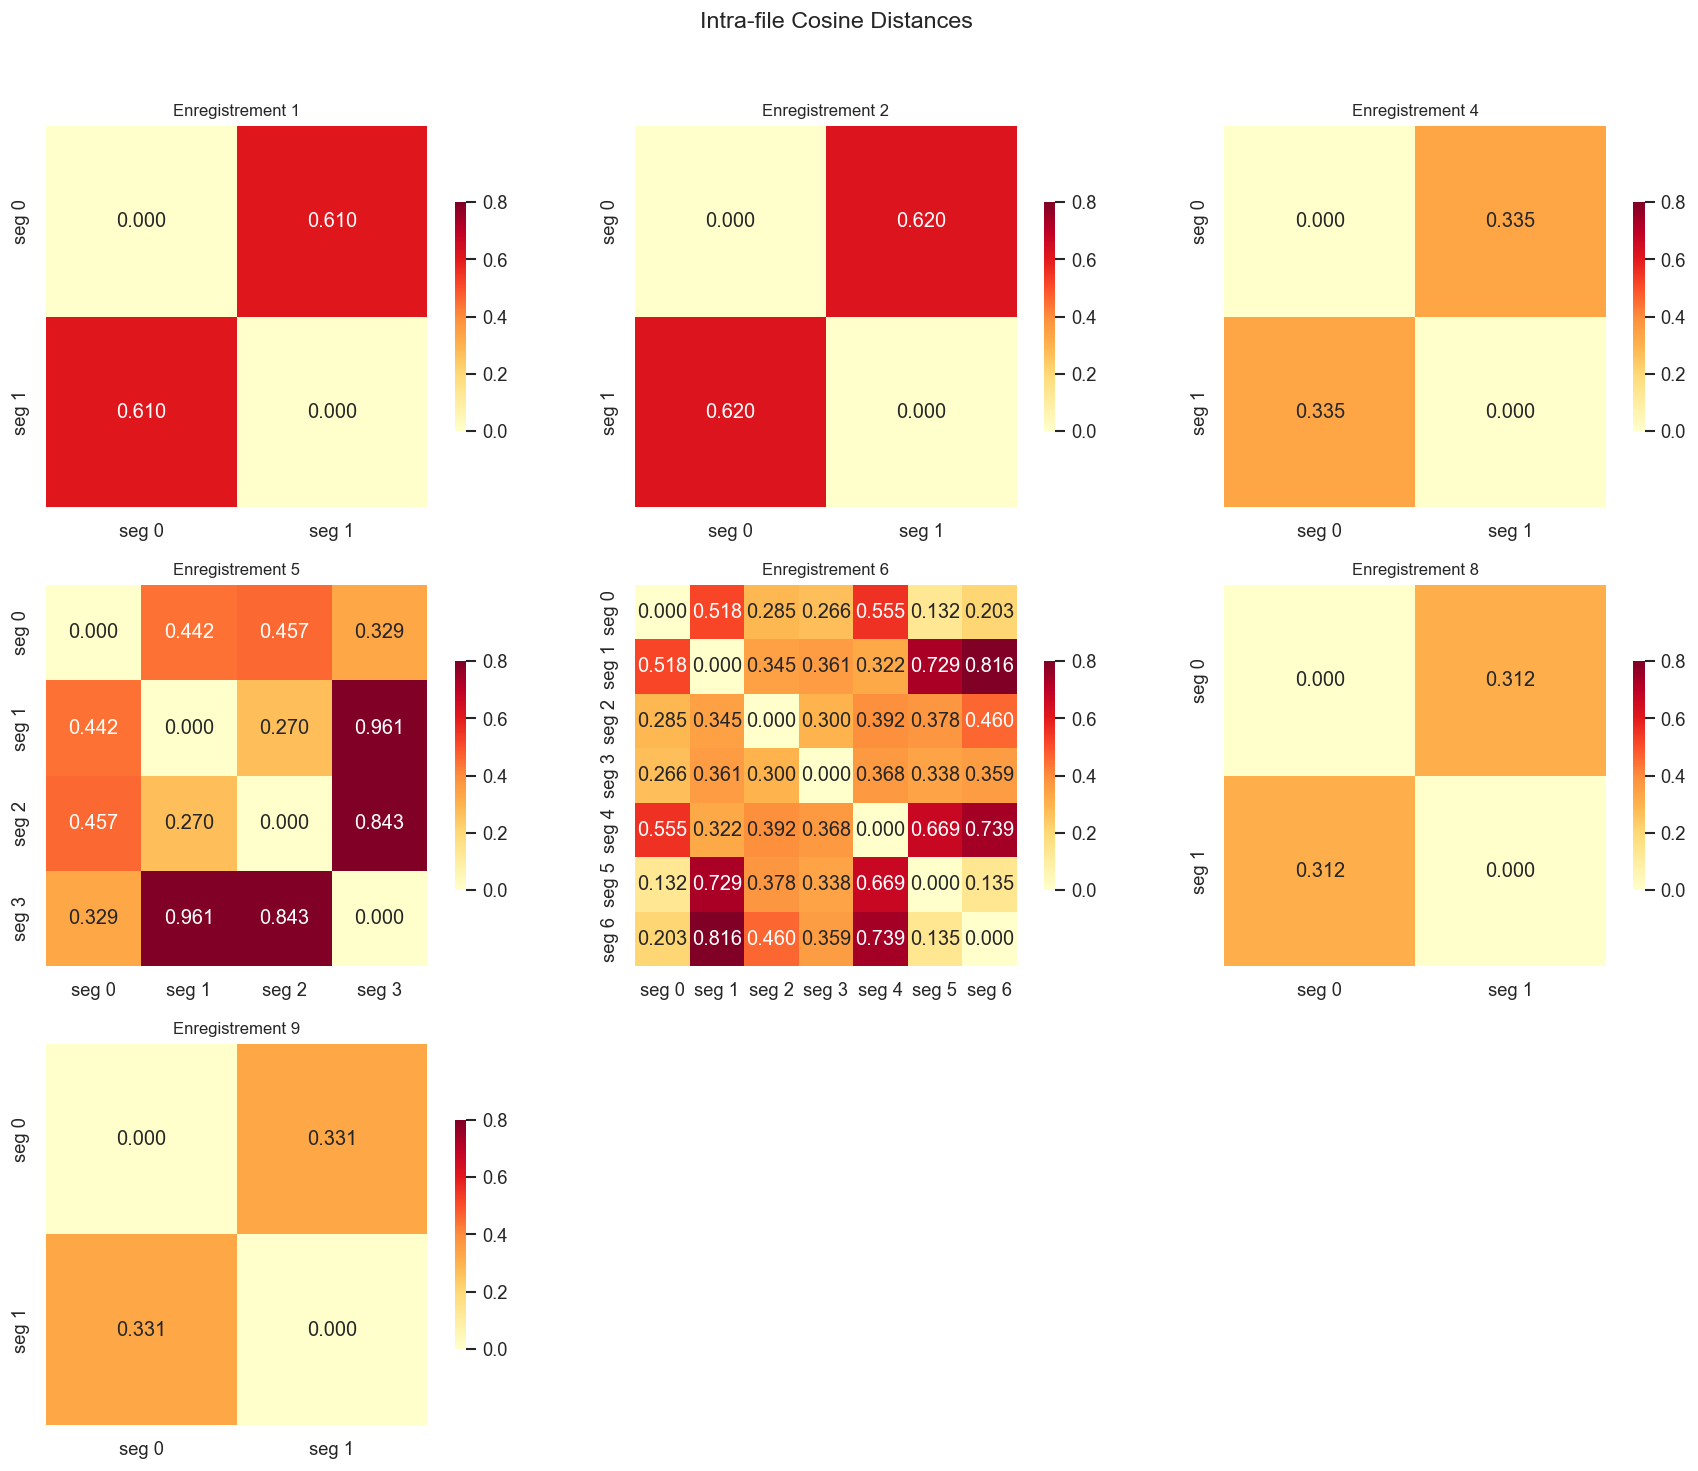

In [22]:
multi_seg_files = df.groupby("file").filter(lambda g: len(g) > 1)["file"].unique()

n_files = len(multi_seg_files)
if n_files > 0:
    cols = min(3, n_files)
    rows_grid = (n_files + cols - 1) // cols
    fig, axes = plt.subplots(rows_grid, cols, figsize=(5 * cols, 4 * rows_grid))
    axes = np.atleast_2d(axes)

    for idx, fname in enumerate(sorted(multi_seg_files)):
        ax = axes[idx // cols, idx % cols]
        sub = df[df["file"] == fname]
        emb_sub = np.stack(sub["embedding"].values)
        d = cosine_distances(emb_sub)
        seg_labels = [f"seg {r.seg_idx}" for _, r in sub.iterrows()]

        sns.heatmap(d, ax=ax, annot=True, fmt=".3f", cmap="YlOrRd",
                    xticklabels=seg_labels, yticklabels=seg_labels,
                    vmin=0, vmax=0.8, square=True, cbar_kws={"shrink": 0.6})
        ax.set_title(fname, fontsize=10)

    # Hide unused axes
    for idx in range(n_files, rows_grid * cols):
        axes[idx // cols, idx % cols].set_visible(False)

    plt.suptitle("Intra-file Cosine Distances", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No files with multiple segments to compare.")

## 7. Cluster composition summary

In [23]:
# Which recordings appear in each cluster?
summary = (
    df.groupby("cluster")
    .agg(
        n_segments=("seg_idx", "count"),
        recordings=("file", lambda x: ", ".join(sorted(x.unique()))),
        n_recordings=("file", "nunique"),
    )
    .reset_index()
    .sort_values("cluster")
)

print("Cluster composition:")
print(summary.to_string(index=False))

Cluster composition:
 cluster  n_segments                                                                               recordings  n_recordings
       0           2                                                                         Enregistrement 4             1
       1           8 Enregistrement 5, Enregistrement 6, Enregistrement 7, Enregistrement 8, Enregistrement 9             5
       2           4                                     Enregistrement 5, Enregistrement 6, Enregistrement 8             3
       3           4                                                       Enregistrement 5, Enregistrement 6             2
       4           2                                                       Enregistrement 1, Enregistrement 2             2
       5           1                                                                         Enregistrement 3             1
       6           1                                                                         Enregistrement 2  

## 8. Sensitivity analysis — varying epsilon

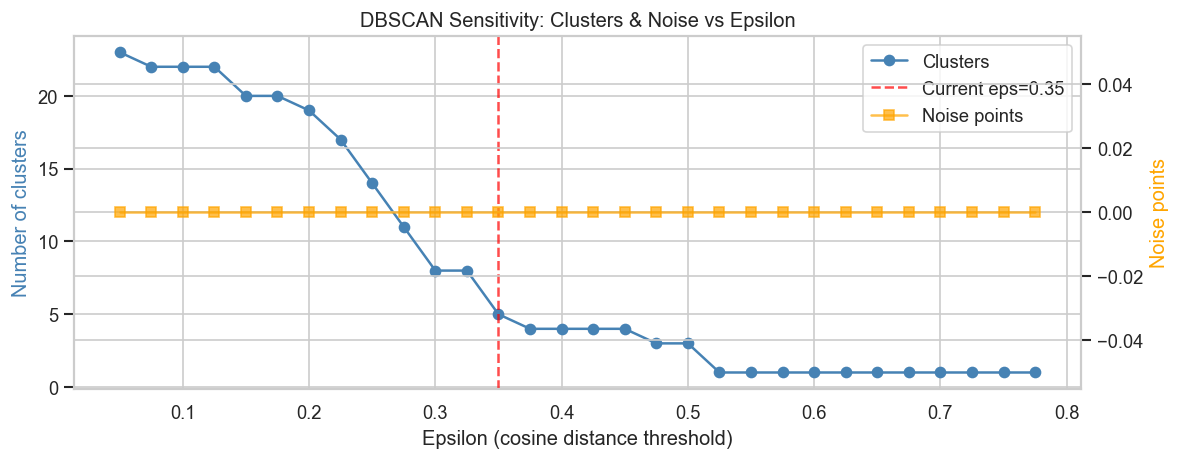

In [24]:
eps_values = np.arange(0.05, 0.80, 0.025)
results = []
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=1, metric="precomputed")
    labels = db.fit_predict(dist_matrix)
    n_c = len(set(labels)) - (1 if -1 in labels else 0)
    n_n = (labels == -1).sum()
    results.append({"eps": eps, "n_clusters": n_c, "n_noise": n_n})

res_df = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(res_df["eps"], res_df["n_clusters"], "o-", color="steelblue", label="Clusters")
ax1.set_xlabel("Epsilon (cosine distance threshold)")
ax1.set_ylabel("Number of clusters", color="steelblue")
ax1.axvline(0.35, color="red", linestyle="--", alpha=0.7, label="Current eps=0.35")

ax2 = ax1.twinx()
ax2.plot(res_df["eps"], res_df["n_noise"], "s-", color="orange", alpha=0.7, label="Noise points")
ax2.set_ylabel("Noise points", color="orange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("DBSCAN Sensitivity: Clusters & Noise vs Epsilon")
plt.tight_layout()
plt.show()

## 9. Interactive 3D UMAP (Plotly)

In [25]:
import plotly.express as px

reducer_3d = umap.UMAP(
    n_components=3,
    metric="cosine",
    n_neighbors=min(5, len(df) - 1),
    min_dist=0.1,
    random_state=42,
)
coords_3d = reducer_3d.fit_transform(embeddings)
df["umap_3d_x"] = coords_3d[:, 0]
df["umap_3d_y"] = coords_3d[:, 1]
df["umap_3d_z"] = coords_3d[:, 2]
df["label"] = df.apply(lambda r: f"{r.file} seg {r.seg_idx}", axis=1)
df["cluster_str"] = df["cluster"].astype(str)

fig = px.scatter_3d(
    df, x="umap_3d_x", y="umap_3d_y", z="umap_3d_z",
    color="cluster_str",
    hover_name="label",
    hover_data={"file": True, "seg_idx": True, "offset_ms": True, "duration_ms": True,
                "umap_3d_x": False, "umap_3d_y": False, "umap_3d_z": False, "cluster_str": False},
    title="3D UMAP — Speaker Embeddings by DBSCAN Cluster",
    labels={"cluster_str": "Cluster"},
    width=800, height=600,
)
fig.update_traces(marker=dict(size=6, line=dict(width=1, color="black")))
fig.show()

/Users/antonin.riche/Documents/perso/notetaker-v2/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 10. Single large 2D speaker map (average linkage)

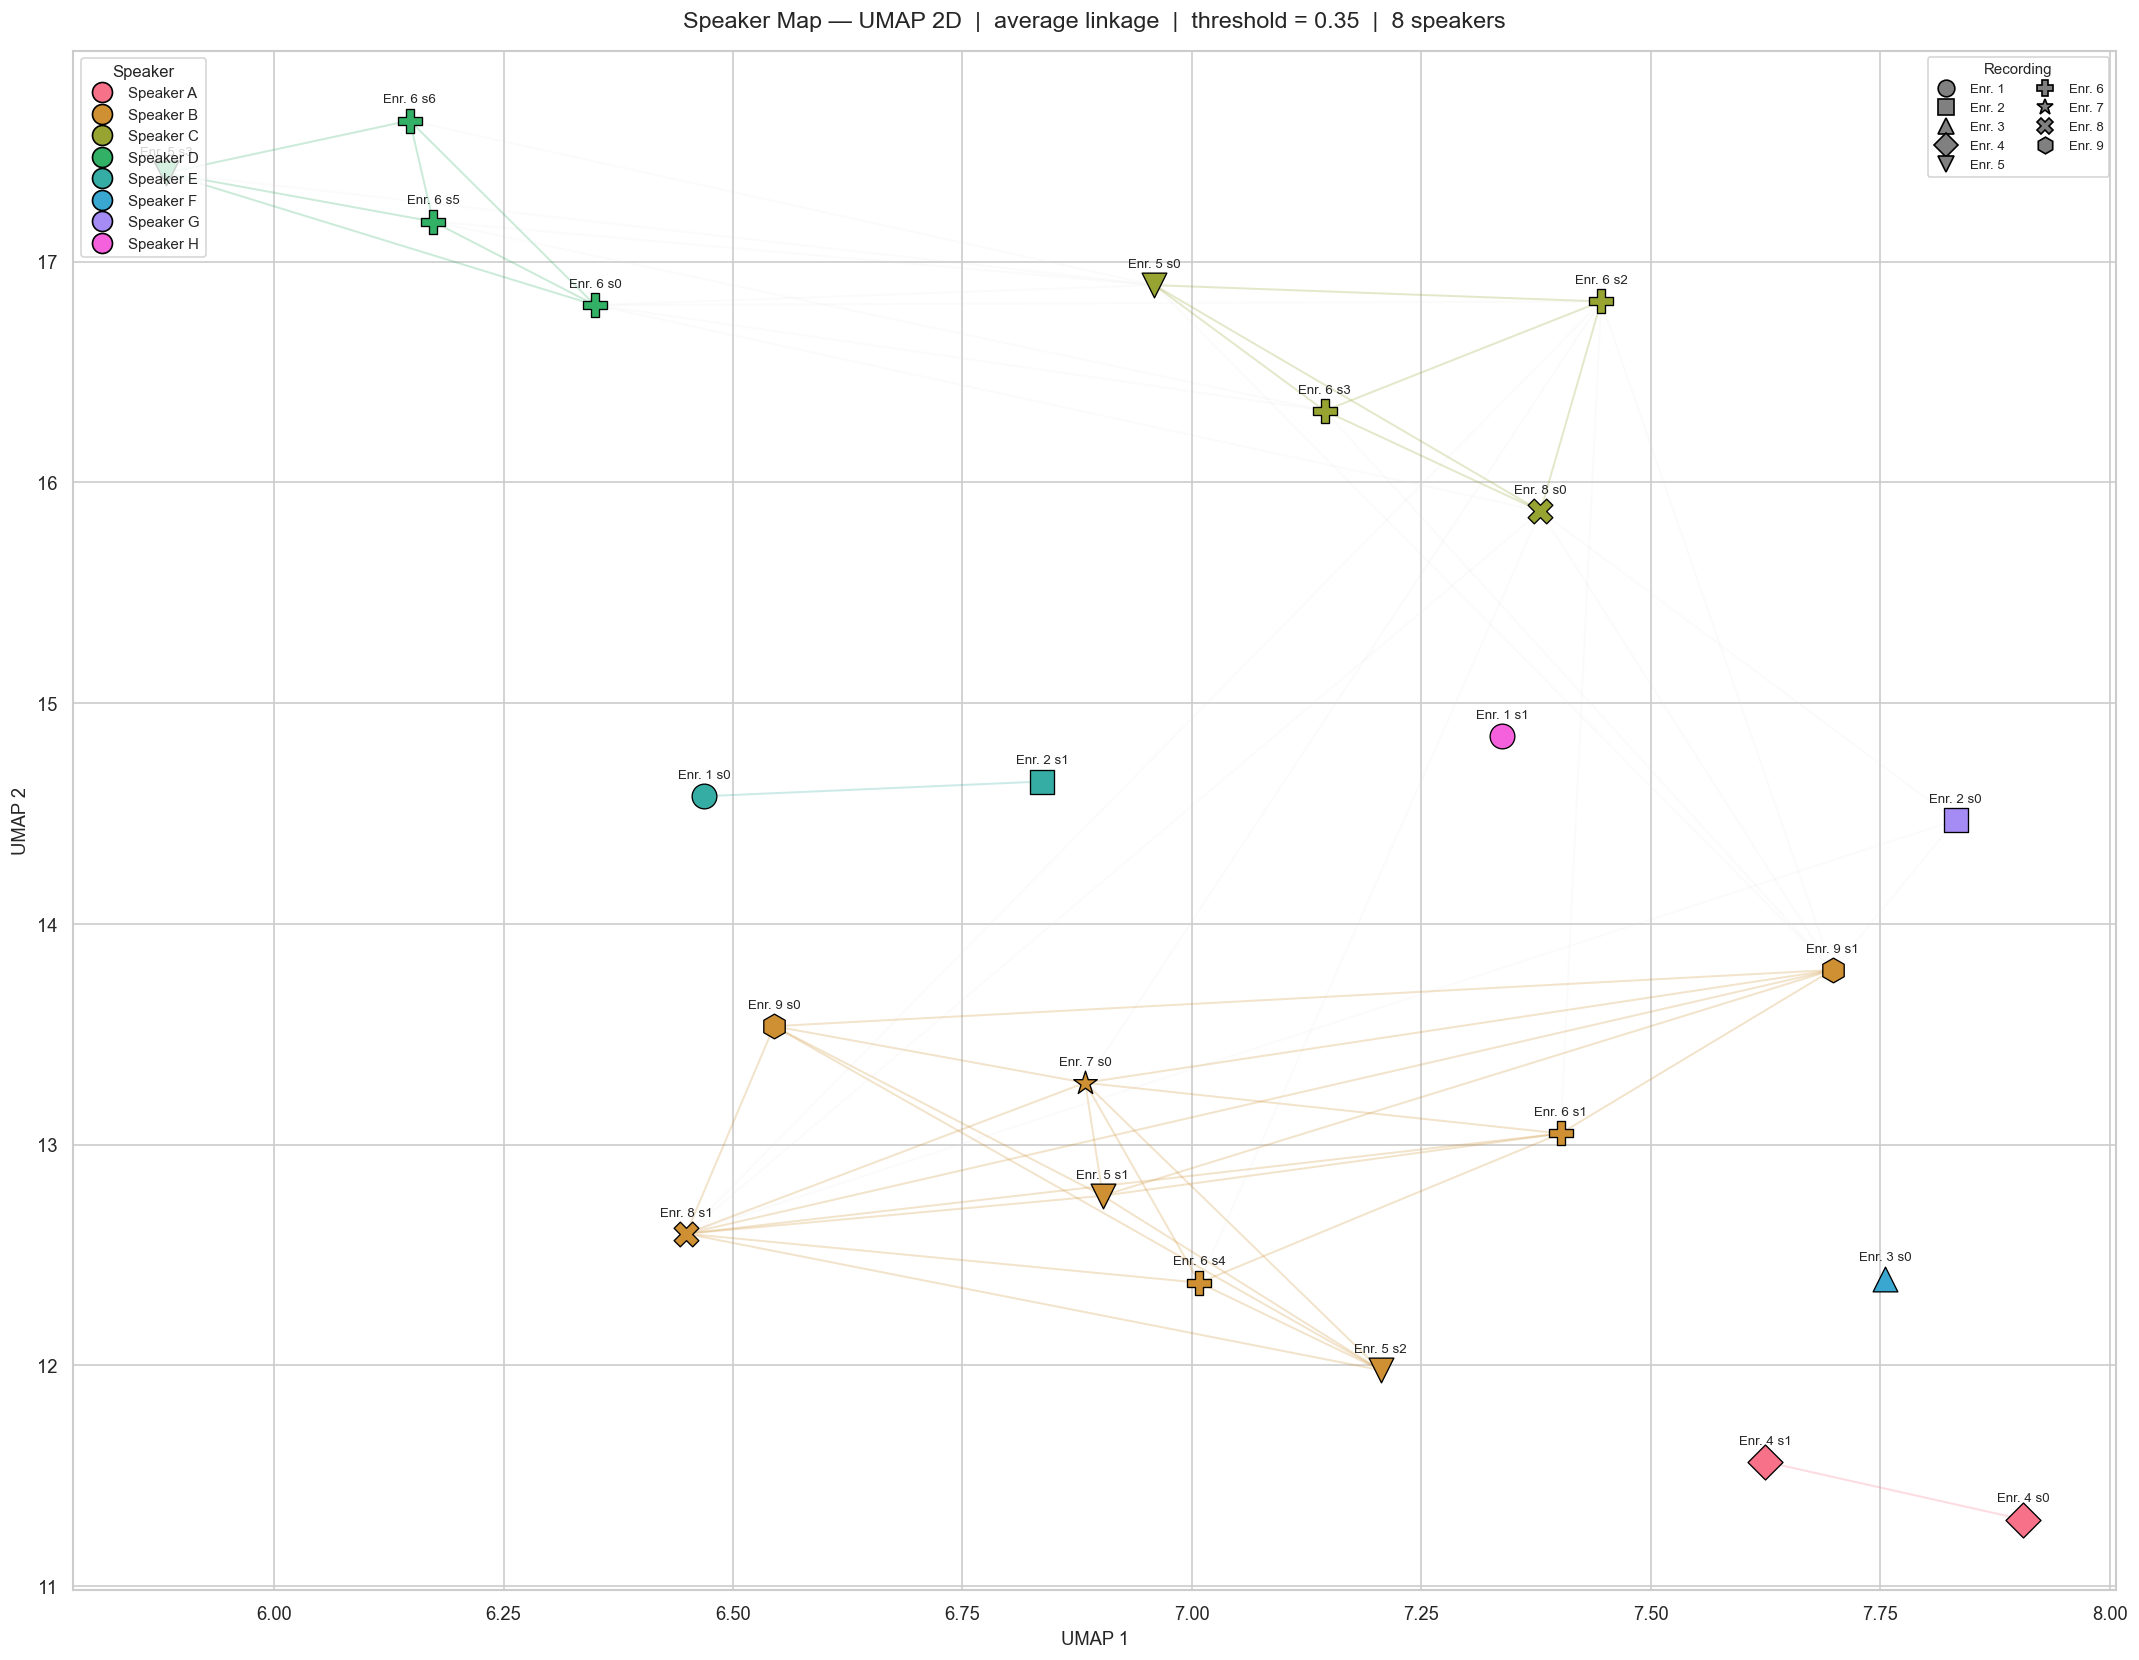

In [26]:
from matplotlib.lines import Line2D

# Use UMAP coords already computed in section 5 (df["umap_x"], df["umap_y"])
# and average-linkage speaker labels from df["speaker"]

speaker_ids = sorted(df["speaker"].unique())
pal = sns.color_palette("husl", n_colors=len(speaker_ids))
sp_colors = {s: pal[i] for i, s in enumerate(speaker_ids)}

fig, ax = plt.subplots(figsize=(18, 14))

# Draw edges between neighbour segments (distance ≤ threshold)
for i, j in neighbor_edges:
    same = df.iloc[i]["speaker"] == df.iloc[j]["speaker"]
    color = sp_colors[df.iloc[i]["speaker"]] if same else "#e0e0e0"
    ax.plot(
        [df.iloc[i]["umap_x"], df.iloc[j]["umap_x"]],
        [df.iloc[i]["umap_y"], df.iloc[j]["umap_y"]],
        color=color, alpha=0.25 if same else 0.12, linewidth=1.2, zorder=1,
    )

# Draw points
for _, row in df.iterrows():
    ax.scatter(
        row["umap_x"], row["umap_y"],
        c=[sp_colors[row["speaker"]]], marker=file_markers[row["file"]],
        s=220, edgecolors="black", linewidth=0.8, zorder=3,
    )
    ax.annotate(
        row["point_label"], (row["umap_x"], row["umap_y"]),
        fontsize=8, ha="center", va="bottom",
        textcoords="offset points", xytext=(0, 9),
    )

# Speaker colour legend
speaker_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=sp_colors[s],
           markersize=12, markeredgecolor="black", label=s)
    for s in speaker_ids
]

# File-shape legend
shape_handles = [
    Line2D([0], [0], marker=file_markers[f], color="w", markerfacecolor="grey",
           markersize=10, markeredgecolor="black",
           label=f.replace("Enregistrement ", "Enr. "))
    for f in file_names
]

leg1 = ax.legend(handles=speaker_handles, title="Speaker", loc="upper left",
                 fontsize=9, title_fontsize=10)
ax.add_artist(leg1)
ax.legend(handles=shape_handles, title="Recording", loc="upper right",
          fontsize=8, title_fontsize=9, ncol=2)

ax.set_title(
    f"Speaker Map — UMAP 2D  |  average linkage  |  threshold = {THRESHOLD}  |  {df['speaker'].nunique()} speakers",
    fontsize=14, pad=14,
)
ax.set_xlabel("UMAP 1", fontsize=11)
ax.set_ylabel("UMAP 2", fontsize=11)
plt.tight_layout()
plt.show()
